# **1. Perkenalan Dataset**

Dataset yang digunakan adalah Customer Segmentation. Dataset berisi informasi umur, total gaji, total pengeluaran, frekuensi transaksi tahunan, dan status membership pelanggan. Tujuan eksperimen ini adalah menyiapkan data agar siap digunakan untuk melatih model klasifikasi status membership.

# **2. Import Library**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler


# **3. Memuat Dataset**

In [2]:
raw_path = '../CustomerSegmentation_raw.csv'
df = pd.read_csv(raw_path)
df.head()


,Age,Total Salary (IDR),Total Spending (IDR),Frequency (Yearly),Membership Status
0,26,199512824,33058318,38,Silver
1,22,62700198,16709332,56,Platinum
2,40,69997972,37973439,46,Gold
3,50,173505245,70738589,26,Gold
4,55,88667694,71184465,39,Gold


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   1000 non-null   int64 
 1   Total Salary (IDR)    1000 non-null   int64 
 2   Total Spending (IDR)  1000 non-null   int64 
 3   Frequency (Yearly)    1000 non-null   int64 
 4   Membership Status     1000 non-null   object
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


# **4. Exploratory Data Analysis (EDA)**

EDA dilakukan untuk memahami ukuran data, tipe data, missing value, duplikasi, distribusi numerik, serta distribusi target.

In [4]:
print('Shape:', df.shape)
print('\nMissing values:')
print(df.isna().sum())
print('\nDuplicate rows:', df.duplicated().sum())
df.describe(include='all')


Shape: (1000, 5)

Missing values:
Age                     0
Total Salary (IDR)      0
Total Spending (IDR)    0
Frequency (Yearly)      0
Membership Status       0
dtype: int64

Duplicate rows: 0


,Age,Total Salary (IDR),Total Spending (IDR),Frequency (Yearly),Membership Status
count,1000.000000,1.000000e+03,1.000000e+03,1000.000000,1000
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Platinum
freq,NaN,NaN,NaN,NaN,339
mean,43.602000,1.259336e+08,5.424983e+07,35.791000,NaN
std,15.208251,4.293481e+07,2.575440e+07,13.538117,NaN
min,18.000000,5.008358e+07,1.000898e+07,12.000000,NaN
25%,30.000000,9.110046e+07,3.194115e+07,25.000000,NaN
50%,43.000000,1.264071e+08,5.388625e+07,36.000000,NaN
75%,57.000000,1.614223e+08,7.626005e+07,47.000000,NaN


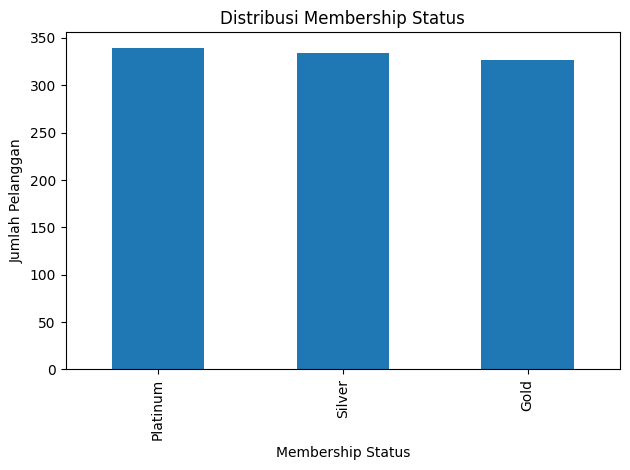

In [5]:
df['Membership Status'].value_counts().plot(kind='bar', title='Distribusi Membership Status')
plt.xlabel('Membership Status')
plt.ylabel('Jumlah Pelanggan')
plt.tight_layout()
plt.show()


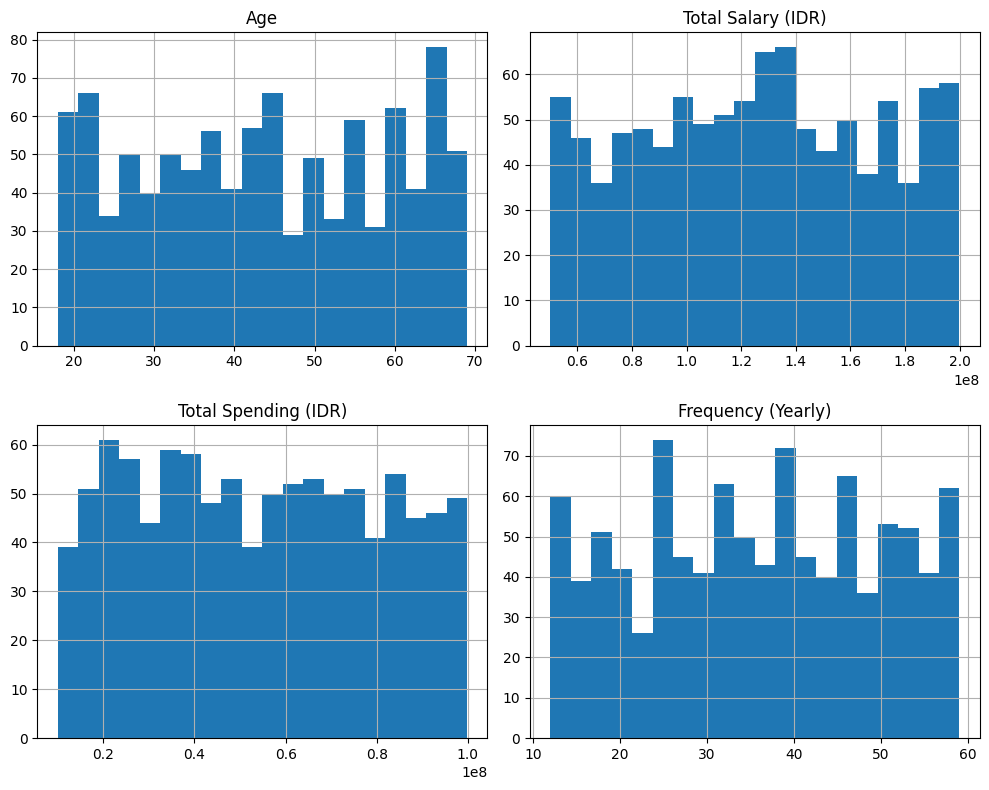

In [6]:
numeric_columns = ['Age', 'Total Salary (IDR)', 'Total Spending (IDR)', 'Frequency (Yearly)']
df[numeric_columns].hist(figsize=(10, 8), bins=20)
plt.tight_layout()
plt.show()


# **5. Data Preprocessing**

Tahapan preprocessing yang digunakan: menghapus duplikasi, memastikan kolom numerik bertipe angka, menghapus missing value, encoding target, dan standardisasi fitur numerik.

In [7]:
feature_columns = ['Age', 'Total Salary (IDR)', 'Total Spending (IDR)', 'Frequency (Yearly)']
target_column = 'Membership Status'

clean_df = df.drop_duplicates().copy()
clean_df = clean_df.dropna(subset=feature_columns + [target_column]).copy()

for column in feature_columns:
    clean_df[column] = pd.to_numeric(clean_df[column], errors='coerce')
clean_df = clean_df.dropna(subset=feature_columns).copy()

label_encoder = LabelEncoder()
clean_df['membership_status_label'] = label_encoder.fit_transform(clean_df[target_column])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(clean_df[feature_columns])
processed_df = pd.DataFrame(
    scaled_features,
    columns=['age_scaled', 'total_salary_idr_scaled', 'total_spending_idr_scaled', 'frequency_yearly_scaled']
)
processed_df['membership_status_label'] = clean_df['membership_status_label'].to_numpy()
processed_df['membership_status'] = clean_df[target_column].to_numpy()
processed_df.head()


,age_scaled,total_salary_idr_scaled,total_spending_idr_scaled,frequency_yearly_scaled,membership_status_label,membership_status
0,-1.157977,1.714601,-0.823242,0.163251,2,Silver
1,-1.421124,-1.473513,-1.458364,1.493495,1,Platinum
2,-0.236964,-1.303455,-0.632301,0.754470,0,Gold
3,0.420903,1.108552,0.640551,-0.723579,0,Gold
4,0.749837,-0.868398,0.657872,0.237153,0,Gold


In [8]:
output_dir = 'CustomerSegmentation_preprocessing'
import os
os.makedirs(output_dir, exist_ok=True)
processed_df.to_csv(f'{output_dir}/customer_segmentation_preprocessed.csv', index=False)
pd.DataFrame({
    'membership_status': label_encoder.classes_,
    'membership_status_label': range(len(label_encoder.classes_))
}).to_csv(f'{output_dir}/label_mapping.csv', index=False)
processed_df.shape


(1000, 6)